In [16]:
"""
Load EOM outputs and compute 1D (ω3, τ3) and 2D (ω3, ω1) spectra.

This mirrors existing NumPy/FFT pipeline, but reads .npy complex arrays.
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
import os
from numpy.fft import fft, fftshift, fftfreq


# Configure LaTeX fonts using rcParams
mpl.rcParams.update({
    'font.size': 14,         # Set font size
    'font.family': 'serif',  # Use serif font
    'text.usetex': True       # Use LaTeX to render text
})

In [17]:
# -------------------
# Load arrays & metadata (pump–probe suffix _pp)
# -------------------
alpha11n1 = np.load("alpha11n1_pp.npy")  # shape (N_t, N_tau1)
alpha1n11 = np.load("alpha1n11_pp.npy")
alphan111 = np.load("alphan111_pp.npy")
alpha001  = np.load("alpha001_pp.npy")

times = np.load("times_pp.npy")
tau1_values = np.load("tau1_values.npy")

with open("meta_pp.json", "r") as f:
    meta = json.load(f)

kappa = meta["kappa"]

# steps
dt   = float(np.mean(np.diff(times)))
dtau = float(np.mean(np.diff(tau1_values)))


In [18]:
N_t, N_tau1 = alpha11n1.shape

# -------------------
# Frequencies (rad/time-unit) with shift 
# -------------------
freq_t    = -fftshift(2*np.pi*fftfreq(N_t,    d=dt))     # ω3
freq_tau1 = -fftshift(2*np.pi*fftfreq(N_tau1, d=dtau))   # ω1

# -------------------
# 1) FFT along time t (axis=0) → (ω3, τ1)
# -------------------
dft_alpha11n1_t = fftshift(fft(alpha11n1, axis=0), axes=0)
dft_alpha1n11_t = fftshift(fft(alpha1n11, axis=0), axes=0)
dft_alphan111_t = fftshift(fft(alphan111, axis=0), axes=0)
dft_resultslin  = fftshift(fft(alpha001,  axis=0), axes=0)  # like before

# -------------------
# 2) Multiply in (ω3, τ1) domain
# -------------------
Z1_ttau = (kappa/2.0)**2 * np.real(np.conjugate(dft_resultslin)*dft_alpha11n1_t )
Z2_ttau = (kappa/2.0)**2 * np.real(np.conjugate(dft_resultslin)*(dft_alpha1n11_t))
Z3_ttau = (kappa/2.0)**2 * np.real(np.conjugate(dft_resultslin)*dft_alphan111_t)

# -------------------
# 3) FFT along τ1 (axis=1) → final (ω3, ω1)
# -------------------
dft_alpha11n1 = fftshift(fft(Z1_ttau, axis=1), axes=1)
dft_alpha1n11 = fftshift(fft(Z2_ttau, axis=1), axes=1)
dft_alphan111 = fftshift(fft(Z3_ttau, axis=1), axes=1)


Z1plot = np.real(dft_alpha11n1)
Z2plot = np.real(dft_alpha1n11)
Z3plot = np.real(dft_alphan111)

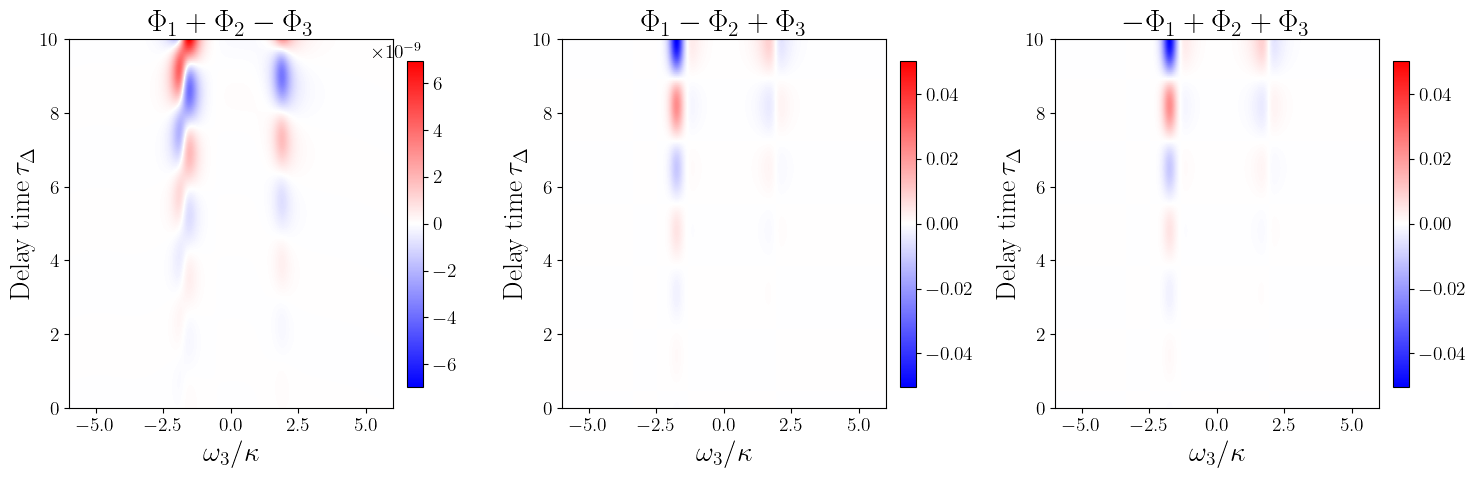

In [19]:
# Limits for color
vmax1 = np.nanmax(np.abs(Z1_ttau))
vmax2 = np.nanmax(np.abs(Z2_ttau))
vmax3 = np.nanmax(np.abs(Z3_ttau))

vmin1, vmin2, vmin3 = -vmax1, -vmax2, -vmax3
# Or use actual τ3 values:
tau3_vals = np.arange(N_tau1) * dtau
extent_ttau = [freq_t[0], freq_t[-1], tau3_vals[0], tau3_vals[-1]]

# -----------------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Z1
im1 = axs[0].imshow(
    Z1_ttau.T, extent=extent_ttau, aspect='auto', cmap='bwr', origin='lower',
    vmin=vmin1, vmax=vmax1
)
axs[0].set_title(r'$\Phi_1+\Phi_2-\Phi_3$', fontsize=22)
axs[0].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[0].set_ylabel(r'Delay time\,$\tau_\Delta$', fontsize=20)
axs[0].set_xlim(-6,6)
fig.colorbar(im1, ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)

# Z2
im2 = axs[1].imshow(
    Z2_ttau.T, extent=extent_ttau, aspect='auto', cmap='bwr', origin='lower',
    vmin=vmin2, vmax=vmax2
)
axs[1].set_title(r'$\Phi_1-\Phi_2+\Phi_3$', fontsize=22)
axs[1].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[1].set_ylabel(r'Delay time\,$\tau_\Delta$', fontsize=20)
axs[1].set_xlim(-6,6)
fig.colorbar(im2, ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)

# Z3
im3 = axs[2].imshow(
    Z3_ttau.T, extent=extent_ttau, aspect='auto', cmap='bwr', origin='lower',
    vmin=vmin3, vmax=vmax3
)
axs[2].set_title(r'$-\Phi_1+\Phi_2+\Phi_3$', fontsize=22)
axs[2].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[2].set_ylabel(r'Delay time\,$\tau_\Delta$', fontsize=20)
axs[2].set_xlim(-6,6)
fig.colorbar(im3, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

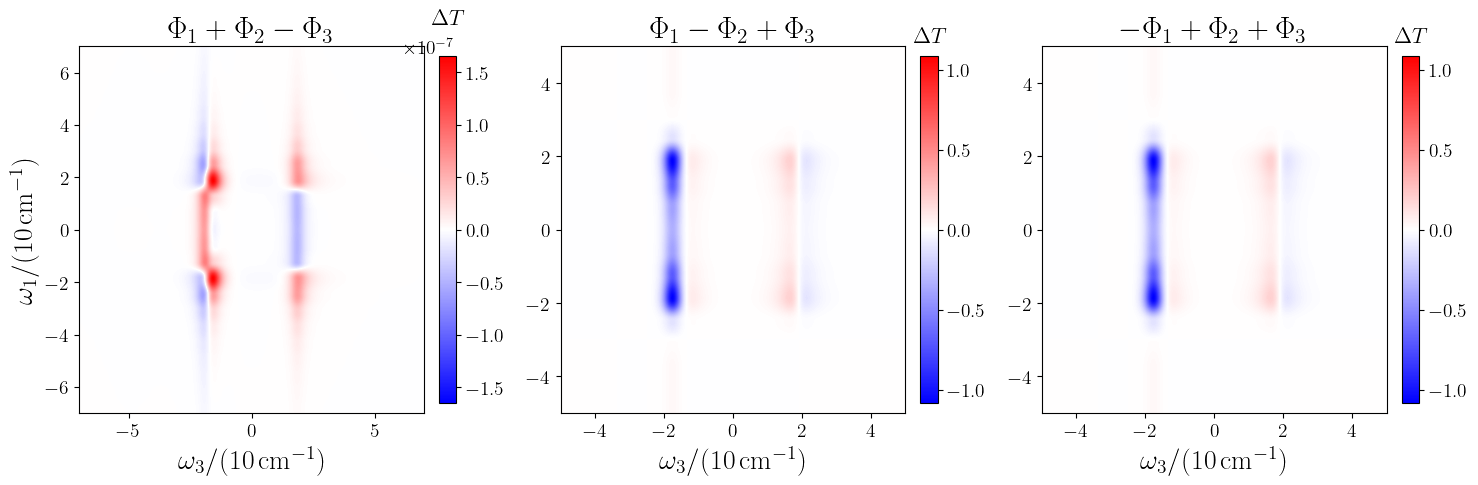

In [20]:
# For each Z*, get its own max absolute value
vmax1 = np.abs(Z1plot).max()
vmax2 = np.abs(Z2plot).max()
vmax3 = np.abs(Z3plot).max()

vmin1, vmin2, vmin3 = -vmax1, -vmax2, -vmax3

fig, axs = plt.subplots(1, 3, figsize=(15, 5))


# Build an 'extent' so imshow has real frequency axis.
# freq_t runs from freq_t[0] to freq_t[-1] (negative to positive)
# freq_tau3 from freq_tau3[0] to freq_tau3[-1].
extent = [freq_t[0], freq_t[-1],  freq_tau1[0], freq_tau1[-1]]

###################################
# Plot Z1 with its own vmin/vmax
###################################
im1 = axs[0].imshow(
    Z1plot.T,
    extent=extent,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin1,
    vmax=vmax1
)

axs[0].set_title(r'$\Phi_1+\Phi_2-\Phi_3$', fontsize=22)
axs[0].set_xlabel(r'$\omega_3/ (10\,\mathrm{cm}^{-1})$', fontsize=20)
axs[0].set_ylabel(r'$\omega_1/ (10\,\mathrm{cm}^{-1})$', fontsize=20)
axs[0].set_xlim(-7, 7)
axs[0].set_ylim(-7, 7)

# -----------------------------------
# Create first colorbar
# -----------------------------------
cbar1 = fig.colorbar(im1, ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)
# Use set_title to add a label on top of the colorbar
cbar1.ax.set_title(r'$\Delta T$', pad=10, fontsize=16)

###################################
# Plot Z2 with its own vmin/vmax
###################################
im2 = axs[1].imshow(
    Z2plot.T,
    extent=extent,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin2,
    vmax=vmax2
)

axs[1].set_title(r'$\Phi_1-\Phi_2+\Phi_3$', fontsize=22)
axs[1].set_xlabel(r'$\omega_3/ (10\,\mathrm{cm}^{-1})$', fontsize=20)
axs[1].set_xlim(-5, 5)
axs[1].set_ylim(-5, 5)


# -----------------------------------
# Create second colorbar
# -----------------------------------
cbar2 = fig.colorbar(im2, ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar2.ax.set_title(r'$\Delta T$', pad=10, fontsize=16)

###################################
# Plot Z3 with its own vmin/vmax
###################################
im3 = axs[2].imshow(
    Z3plot.T,
    extent=extent,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin3,
    vmax=vmax3
)

axs[2].set_title(r'$-\Phi_1+\Phi_2+\Phi_3$', fontsize=22)
axs[2].set_xlabel(r'$\omega_3/ (10\,\mathrm{cm}^{-1})$', fontsize=20)
axs[2].set_xlim(-5, 5)
axs[2].set_ylim(-5, 5)




    

# -----------------------------------
# Create third colorbar
# -----------------------------------
cbar3 = fig.colorbar(im3, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
cbar3.ax.set_title(r'$\Delta T$', pad=10, fontsize=16)

plt.tight_layout()
plt.savefig("2D_spectra_2LS_smalldelay.pdf", bbox_inches='tight')
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
C:\Users\michr\AppData\Local\Temp\ipykernel_24940\2532129376.py:12: SyntaxWarning: invalid escape sequence '\D'
  ax3.set_ylabel('$-\Delta T$', fontsize=18)


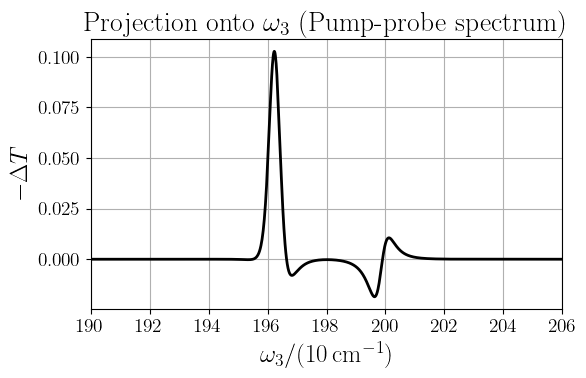

In [21]:
# Sum over y-axis (omega_1) to project onto omega_3 (x-axis of original Z3prod before .T)
projection_y3 = np.sum(Z3plot, axis=1)

# Generate corresponding omega_3 values from extent (i.e., x-axis in imshow)
omega3_vals = np.linspace(extent[0], extent[1], Z3plot.shape[0])

# Create new figure for the omega_3 projection
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(omega3_vals+198, -projection_y3, color='black', linewidth=2)
ax3.set_title('Projection onto $\\omega_3$ (Pump-probe spectrum)', fontsize=20)
ax3.set_xlabel(r'$\omega_3 / (10\,\mathrm{cm}^{-1})$', fontsize=18)
ax3.set_ylabel('$-\Delta T$', fontsize=18)
ax3.grid(True)
ax3.set_xlim(190,206)

plt.tight_layout()
plt.savefig("1dspectra_newdefinition.pdf", bbox_inches='tight')
plt.show()

In [22]:
# ---------- 1) Load experiment CSVs ----------
folder_path = os.getcwd()  # or set an explicit path
file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])

if len(file_names) == 0:
    raise FileNotFoundError("No .csv files found in the current folder. "
                            "Place the Harsh data CSVs in this directory.")

data_arrays = []
x_vals_list = []
y_vals_list = []

for file_name in file_names:
    df = pd.read_csv(os.path.join(folder_path, file_name), header=None)
    x_vals = df.iloc[0, 1:].to_numpy()         # header row (skip top-left corner)
    y_vals = df.iloc[1:, 0].to_numpy()         # first column (skip top-left corner)
    data = df.iloc[1:, 1:].to_numpy(dtype=float)
    x_vals_list.append(x_vals)
    y_vals_list.append(y_vals)
    data_arrays.append(data)

# Choose "File 3" (0-based index 2)
file_idx = 1
if file_idx >= len(data_arrays):
    raise IndexError(f"Requested File 3 (index 2) but only {len(data_arrays)} CSV files were found.")

exp_data = data_arrays[file_idx]
exp_x = x_vals_list[file_idx]
exp_y = y_vals_list[file_idx]

print("Experiment x-axis limits:", exp_x.min(), "to", exp_x.max())
print("Experiment y-axis limits:", exp_y.min(), "to", exp_y.max())

Experiment x-axis limits: 1906.6 to 2058.7
Experiment y-axis limits: 1906.8 to 2058.5


In [23]:
# ---------- 2) Get theory data ----------
# Expecting Z1plot defined in this notebook already
try:
    theory_data = Z2plot.T
except NameError as e:
    raise NameError("Z1plot is not defined in this notebook. "
                    "Run the theory cells that produce Z1plot first.") from e

# Try to use real axes if available; else fall back to pixel indices
use_theory_axes = ('freq_t' in globals() and isinstance(freq_t, (np.ndarray, list)) and
                   'freq_tau3' in globals() and isinstance(freq_tau3, (np.ndarray, list)))

if use_theory_axes:
    theory_x = np.asarray(freq_t)
    theory_y = np.asarray(freq_tau3)
else:
    theory_x = np.arange(theory_data.shape[1])
    theory_y = np.arange(theory_data.shape[0])

# ---------- 4) Compute x-axis projections ----------
proj_theory = np.sum(theory_data, axis=0)   # sum over rows (y)
proj_exp    = np.sum(exp_data, axis=0)      # sum over rows (y)

x_theory = theory_x
x_exp    = exp_x

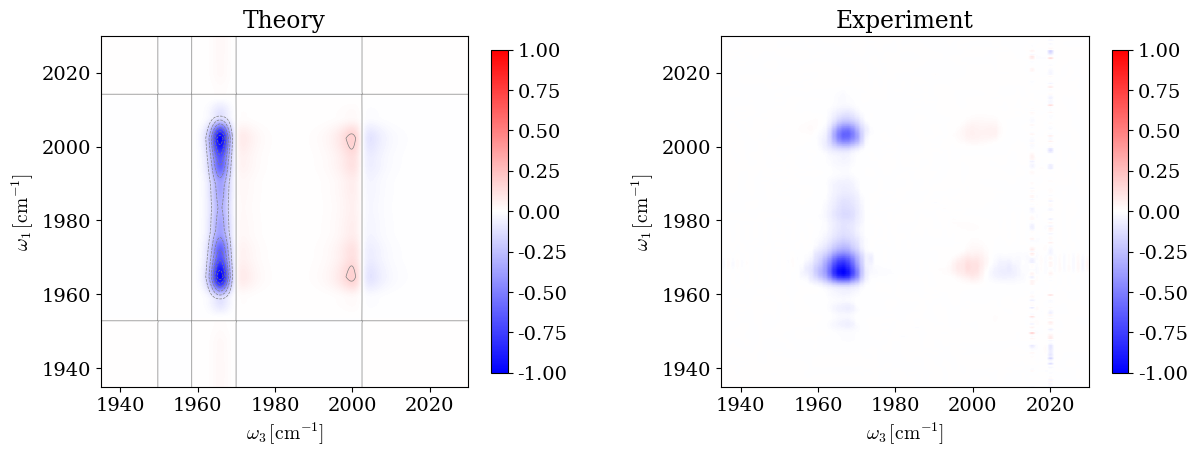

In [24]:
# --- Fixed symmetric normalization ---
norm_fixed = Normalize(vmin=-1, vmax=1)

extent = [freq_t[0]*10 + 1983.5, freq_t[-1]*10 + 1983.5,
          freq_tau1[0]*10 + 1983.5, freq_tau1[-1]*10 + 1983.5]

with mpl.rc_context({'text.usetex': False}):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.set_layout_engine(None)

    # ---------------- Theory ----------------
    im0 = axs[0].imshow(
        Z2plot.T / np.nanmax(np.abs(Z2plot)),   # normalize data to ±1
        extent=extent,
        aspect='auto',
        cmap='bwr',
        origin='lower',
        norm=norm_fixed
    )
    axs[0].contour(
        Z2plot.T / np.nanmax(np.abs(Z2plot)),
        levels=10,
        colors='gray',
        linewidths=0.5,
        extent=extent
    )
    axs[0].set_title("Theory", pad=6)
    axs[0].set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
    axs[0].set_ylabel(r"$\omega_1\,[\mathrm{cm}^{-1}]$")
    axs[0].set_xlim(1935, 2030)
    axs[0].set_ylim(1935, 2030)
    fig.colorbar(im0, ax=axs[0], shrink=0.92)

    # ---------------- Experiment ----------------
    im1 = axs[1].imshow(
        exp_data / np.nanmax(np.abs(exp_data)),  # normalize data to ±1
        extent=[exp_x[0], exp_x[-1], exp_y[0], exp_y[-1]],
        origin='lower',
        aspect='auto',
        cmap='bwr',
        norm=norm_fixed
    )
    axs[1].set_title("Experiment", pad=6)
    axs[1].set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
    axs[1].set_ylabel(r"$\omega_1\,[\mathrm{cm}^{-1}]$")
    axs[1].set_xlim(1935, 2030)
    axs[1].set_ylim(1935, 2030)
    fig.colorbar(im1, ax=axs[1], shrink=0.92)

    # Layout + save
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.9, wspace=0.35)
    plt.show()
    fig.savefig("theory_vs_experiment.pdf", format="pdf", bbox_inches="tight")

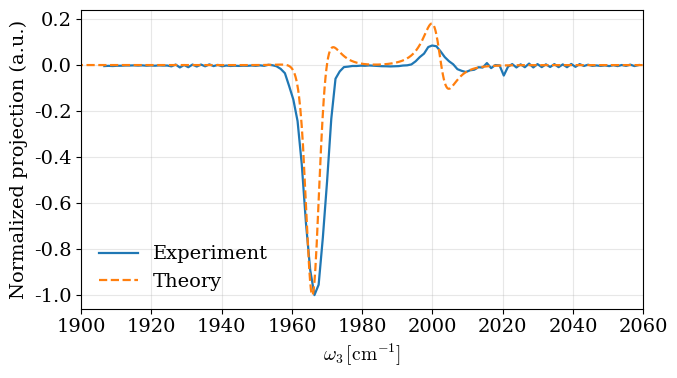

In [25]:
# --------- FIGURE: Combined normalized x-axis projections ----------
with mpl.rc_context({'text.usetex': False}):
    fig, ax = plt.subplots(figsize=(7, 4))
    fig.set_layout_engine(None)

    # Normalize each projection by its maximum absolute value
    proj_theory_norm = proj_theory / np.nanmax(np.abs(proj_theory))
    proj_exp_norm    = proj_exp    / np.nanmax(np.abs(proj_exp))



    # Plot experiment
    ax.plot(exp_x, proj_exp_norm, lw=1.6, label="Experiment")
       # Plot theory (rescaled axis as you had before)
    ax.plot(freq_t*10 + 1983.5, proj_theory_norm, lw=1.6, label="Theory", ls="dashed")
    ax.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
    ax.set_xlim(1900,2060)
    ax.set_ylabel("Normalized projection (a.u.)")
    ax.grid(alpha=0.3)

    ax.legend(frameon=False)

    fig.tight_layout()
    plt.show()
    fig.savefig("theory_vs_experiment_combined.pdf",
                format="pdf", bbox_inches="tight")

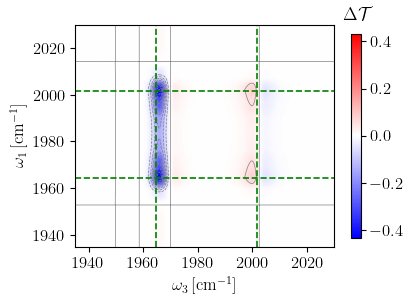

In [26]:
# --- Use real data limits ---
v = np.nanmax(np.abs(Z2plot)/2.5)
norm_real = Normalize(vmin=-v, vmax=v)

extent = [freq_t[0]*10 + 1983.5, freq_t[-1]*10 + 1983.5,
          freq_tau1[0]*10 + 1983.5, freq_tau1[-1]*10 + 1983.5]

center = 1983
delta = 18.5
positions = [center - delta, center + delta]

with mpl.rc_context({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'axes.labelsize': 12,
    'font.size': 12,
    'axes.titlesize': 13,
}):

    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    fig.set_layout_engine(None)

    im = ax.imshow(
        Z2plot.T/2.5,
        extent=extent,
        aspect='auto',
        cmap='bwr',
        origin='lower',
        norm=norm_real
    )

    ax.contour(
        Z2plot.T/2,
        levels=10,
        colors='gray',
        linewidths=0.5,
        extent=extent
    )

       # --- Add dashed green guide lines ---
    for pos in positions:
        ax.axvline(pos, color='green', linestyle='--', linewidth=1.2)
        ax.axhline(pos, color='green', linestyle='--', linewidth=1.2)

    ax.set_xlabel(r"$\omega_3\, [\mathrm{cm}^{-1}]$")
    ax.set_ylabel(r"$\omega_1\, [\mathrm{cm}^{-1}]$")
    ax.set_xlim(1935, 2030)
    ax.set_ylim(1935, 2030)



    cbar = fig.colorbar(im, ax=ax, shrink=0.92)
    cbar.ax.set_title(r"$\Delta\mathcal{T}$", pad=8)

    fig.subplots_adjust(left=0.14, right=0.95, bottom=0.14, top=0.88)

    plt.show()
    fig.savefig("full.pdf", format="pdf", bbox_inches="tight")

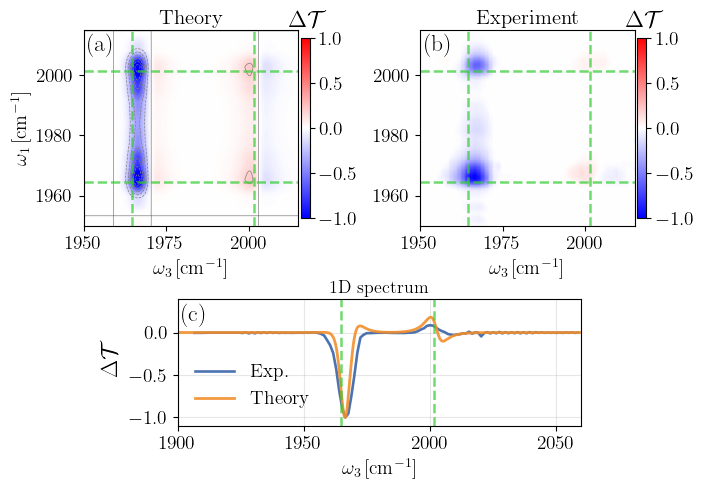

In [27]:
# ---------------- Styling: "LaTeX-like" fonts ----------------
# Option A (robust, no external LaTeX needed): Computer-Modern-like via mathtext
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# Option B (true LaTeX rendering) — enable ONLY if a TeX install is available
# mpl.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "text.latex.preamble": r"\usepackage{amsmath}",
#     "axes.unicode_minus": False,
# })

# ---------------- Fixed symmetric normalization ----------------
norm_fixed = Normalize(vmin=-1, vmax=1)

extent_theory = [
    freq_t[0]*10 + 1984, freq_t[-1]*10 + 1984,
    freq_tau1[0]*10 + 1984, freq_tau1[-1]*10 + 1984
]
extent_exp = [exp_x[0], exp_x[-1], exp_y[0], exp_y[-1]]

Zsum=Z2plot+Z3plot

# Normalize to ±1
Z_theory = (Zsum.T) / np.nanmax(np.abs(Zsum))
Z_exp    = exp_data  / np.nanmax(np.abs(exp_data))

# 1D projections (normalized)
proj_theory_norm = proj_theory / np.nanmax(np.abs(proj_theory))
proj_exp_norm    = proj_exp    / np.nanmax(np.abs(proj_exp))

# ---------------- Combined figure (a)(b)(c) ----------------
fig = plt.figure(figsize=(6.5, 4.5))
fig.set_layout_engine(None)

gs = GridSpec(
    nrows=2, ncols=2, figure=fig,
    height_ratios=[1.0, 0.65],
    hspace=0.45, wspace=0.32
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
# Sub-gridspec for panel (c): 75% width, centered
gs_c = gs[1, :].subgridspec(
    nrows=1, ncols=3,
    width_ratios=[0.125, 0.85, 0.125]
)

ax_c = fig.add_subplot(gs_c[0, 1])

# (a) Theory
im_a = ax_a.imshow(
    Z_theory/0.85,
    extent=extent_theory,
    aspect="auto",
    cmap="bwr",
    origin="lower",
    norm=norm_fixed
)
ax_a.contour(
    Z_theory,
    levels=10,
    colors="gray",
    linewidths=0.5,
    extent=extent_theory
)
ax_a.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_a.set_ylabel(r"$\omega_1\,[\mathrm{cm}^{-1}]$")
lower = 1950
upper = 2030 - (1950 - 1935)   # subtract same amount from top edge

ax_a.set_xlim(lower, upper)
ax_a.set_ylim(lower, upper)

ax_a.text(0.02, 0.98, r"(a)", transform=ax_a.transAxes,
          va="top", ha="left", fontsize=17)

# (b) Experiment
im_b = ax_b.imshow(
    Z_exp,
    extent=extent_exp,
    origin="lower",
    aspect="auto",
    cmap="bwr",
    norm=norm_fixed
)

ax_b.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_b.set_ylabel("")


ax_b.set_xlim(lower, upper)
ax_b.set_ylim(lower, upper)

ax_b.text(0.02, 0.98, r"(b)", transform=ax_b.transAxes,
          va="top", ha="left", fontsize=17)

# Colorbars (one per panel, like your original)
cbar_a = fig.colorbar(im_a, ax=ax_a, shrink=0.92, pad=0.01)
cbar_a.ax.set_title(r"$\Delta\mathcal{T}$", pad=6)

cbar_b = fig.colorbar(im_b, ax=ax_b, shrink=0.92, pad=0.01)
cbar_b.ax.set_title(r"$\Delta\mathcal{T}$", pad=6)

# (c) Projections
# Seaborn "dark" palette
color_exp    = "#4C72B0"   # steelblue (Seaborn deep blue)
color_theory = "#F28E2B"  # bright amber / orange

ax_c.plot(exp_x, proj_exp_norm,
          lw=1.9, color=color_exp, label="Exp.")

ax_c.plot(freq_t*10 + 1984, proj_theory_norm,
          lw=2.0, color=color_theory, label="Theory", alpha=0.9)
ax_c.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_c.set_ylabel(r"$\Delta\mathcal{T}$", fontsize=17)
ax_c.set_xlim(1900, 2060)
ax_c.set_ylim(-1.1, 0.4)
ax_c.grid(alpha=0.3)
ax_c.legend(frameon=False, loc="lower left", fontsize=14)
ax_c.text(0.01, 0.96, r"(c)", transform=ax_c.transAxes,
          va="top", ha="left", fontsize=17)

ax_c.set_title(r"1D spectrum", fontsize=13, pad=4)


#titles
ax_a.set_title("Theory", fontsize=15, pad=4)
ax_b.set_title("Experiment", fontsize=15, pad=4)

# ---------------- Guide lines: 1983 ± 18.5 cm^{-1} ----------------
omega0 = 1983.0
delta  = 18.5
lines  = [omega0 - delta, omega0 + delta]

for ax in (ax_a, ax_b):
    # vertical lines
    for x in lines:
        ax.axvline(x=x, color="limegreen", linestyle="--", lw=1.8, alpha=0.7)
    # horizontal lines
    for y in lines:
        ax.axhline(y=y, color="limegreen", linestyle="--", lw=1.8, alpha=0.7)
# panel (c): vertical lines only
for x in lines:
    ax_c.axvline(x=x, color="limegreen", linestyle="--", lw=1.8, alpha=0.7)

# Final layout + save
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.09, top=0.97)
plt.show()

fig.savefig("fig4.pdf",
            format="pdf", bbox_inches="tight")

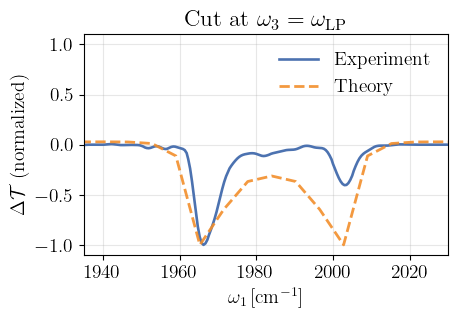

In [28]:
# ===================== FIGURE: CUT COMPARISON (SEPARATE FIGURE) =====================

x_cut = 1983.0 - 18.5   # cm^-1 → 1966.5

# Axes for theory and experiment
x_theory = freq_t * 10 + 1984
y_theory = freq_tau1 * 10 + 1984
x_exp_ax = exp_x
y_exp_ax = exp_y

# Nearest-index cuts at ω3 = x_cut
ix_t = int(np.argmin(np.abs(x_theory - x_cut)))
ix_e = int(np.argmin(np.abs(x_exp_ax - x_cut)))

cut_theory = Z_theory[:, ix_t]   # varies along ω1
cut_exp    = Z_exp[:, ix_e]

# Normalize cuts to ±1 (shape comparison)
cut_theory_norm = cut_theory / np.nanmax(np.abs(cut_theory))
cut_exp_norm    = cut_exp    / np.nanmax(np.abs(cut_exp))

# ---------------- Plot ----------------
fig_cut, ax = plt.subplots(figsize=(4.8, 3.4))

ax.plot(y_exp_ax, cut_exp_norm,
        lw=1.9, color=color_exp, label="Experiment")

ax.plot(y_theory, cut_theory_norm,
        lw=2.0, ls="--", color=color_theory,
        label="Theory", alpha=0.9)

ax.set_xlabel(r"$\omega_1\,[\mathrm{cm}^{-1}]$")
ax.set_ylabel(r"$\Delta\mathcal{T}$ (normalized)")
ax.set_title(r"Cut at $\omega_3 = \omega_{\mathrm{LP}}$", pad=6)

ax.set_xlim(1935, 2030)
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

fig_cut.tight_layout()
plt.show()

fig_cut.savefig("fig_cut_omega3_phismall.pdf",
                format="pdf", bbox_inches="tight")

Text(0.5, 1.0, 'Cut at $\\omega_1 = \\omega_{\\mathrm{LP}}$')

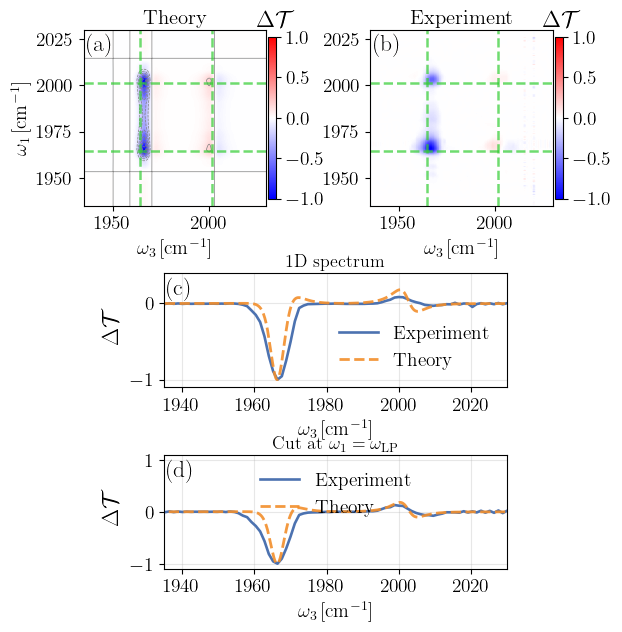

In [29]:
# ---------------- Styling: "LaTeX-like" fonts ----------------
# Option A (robust, no external LaTeX needed): Computer-Modern-like via mathtext
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# Option B (true LaTeX rendering) — enable ONLY if a TeX install is available
# mpl.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "text.latex.preamble": r"\usepackage{amsmath}",
#     "axes.unicode_minus": False,
# })

# ---------------- Fixed symmetric normalization ----------------
norm_fixed = Normalize(vmin=-1, vmax=1)

extent_theory = [
    freq_t[0]*10 + 1984, freq_t[-1]*10 + 1984,
    freq_tau1[0]*10 + 1984, freq_tau1[-1]*10 + 1984
]
extent_exp = [exp_x[0], exp_x[-1], exp_y[0], exp_y[-1]]

# Normalize to ±1
Z_theory = Z2plot.T / np.nanmax(np.abs(Z2plot))
Z_exp    = exp_data  / np.nanmax(np.abs(exp_data))

# 1D projections (normalized)
proj_theory_norm = proj_theory / np.nanmax(np.abs(proj_theory))
proj_exp_norm    = proj_exp    / np.nanmax(np.abs(proj_exp))

# ---------------- Combined figure (a)(b)(c) ----------------
# --- Replace your "Combined figure (a)(b)(c)" block with this layout ---
fig = plt.figure(figsize=(6.5, 7.0))   # <-- taller figure
fig.set_layout_engine(None)

gs = GridSpec(
    nrows=3, ncols=2, figure=fig,
    height_ratios=[1.0, 0.65, 0.65],   # row0: (a)(b), row1: (c), row2: (d)
    hspace=0.50, wspace=0.32
)

x_cut = 1983.0 - 16.5  # cm^-1  -> 1966.5
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

# Panel (c) centered, 75% width (same as you had)
gs_c = gs[1, :].subgridspec(
    nrows=1, ncols=3,
    width_ratios=[0.125, 0.85, 0.125]
)
ax_c = fig.add_subplot(gs_c[0, 1])

# Panel (d) centered, SAME format as (c)
gs_d = gs[2, :].subgridspec(
    nrows=1, ncols=3,
    width_ratios=[0.125, 0.85, 0.125]
)
ax_d = fig.add_subplot(gs_d[0, 1])

# ---------------- Shared x-range for panels (c) and (d) ----------------
xrange_cd = (1935, 2030)

# ---------------- (a) Theory ----------------
im_a = ax_a.imshow(
    Z_theory,
    extent=extent_theory,
    aspect="auto",
    cmap="bwr",
    origin="lower",
    norm=norm_fixed
)
ax_a.contour(
    Z_theory,
    levels=10,
    colors="gray",
    linewidths=0.5,
    extent=extent_theory
)
ax_a.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_a.set_ylabel(r"$\omega_1\,[\mathrm{cm}^{-1}]$")
ax_a.set_xlim(1935, 2030)
ax_a.set_ylim(1935, 2030)
ax_a.text(0.02, 0.98, r"(a)", transform=ax_a.transAxes,
          va="top", ha="left", fontsize=17)
ax_a.set_title("Theory", fontsize=15, pad=4)

# ---------------- (b) Experiment ----------------
im_b = ax_b.imshow(
    Z_exp,
    extent=extent_exp,
    origin="lower",
    aspect="auto",
    cmap="bwr",
    norm=norm_fixed
)
ax_b.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_b.set_ylabel("")
ax_b.set_xlim(1935, 2030)
ax_b.set_ylim(1935, 2030)
ax_b.text(0.02, 0.98, r"(b)", transform=ax_b.transAxes,
          va="top", ha="left", fontsize=17)
ax_b.set_title("Experiment", fontsize=15, pad=4)

# Colorbars (one per panel, like your original)
cbar_a = fig.colorbar(im_a, ax=ax_a, shrink=0.92, pad=0.01)
cbar_a.ax.set_title(r"$\Delta\mathcal{T}$", pad=6)

cbar_b = fig.colorbar(im_b, ax=ax_b, shrink=0.92, pad=0.01)
cbar_b.ax.set_title(r"$\Delta\mathcal{T}$", pad=6)

# ---------------- Guide lines: 1983 ± 18.5 cm^{-1} ----------------
omega0 = 1983.0
delta  = 18.5
lines  = [omega0 - delta, omega0 + delta]

for ax in (ax_a, ax_b):
    for x in lines:
        ax.axvline(x=x, color="limegreen", linestyle="--", lw=1.8, alpha=0.7)
    for y in lines:
        ax.axhline(y=y, color="limegreen", linestyle="--", lw=1.8, alpha=0.7)

# ---------------- (c) Projections ----------------
ax_c.plot(exp_x, proj_exp_norm,
          lw=1.9, color=color_exp, label="Experiment")

ax_c.plot(freq_t*10 + 1984, proj_theory_norm,
          lw=2.0, ls="--", color=color_theory, label="Theory", alpha=0.9)

ax_c.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_c.set_ylabel(r"$\Delta\mathcal{T}$", fontsize=17)
ax_c.set_xlim(*xrange_cd)
ax_c.set_ylim(-1.1, 0.4)
ax_c.grid(alpha=0.3)
ax_c.legend(frameon=False)
ax_c.text(0.01, 0.96, r"(c)", transform=ax_c.transAxes,
          va="top", ha="left", fontsize=17)

ax_c.set_title(r"1D spectrum", fontsize=13, pad=4)

# ---------------- (d) Cut comparison at ω1 = ωLP ----------------
# Axes for the 2D maps
x_theory = freq_t * 10 + 1984
y_theory = freq_tau1 * 10 + 1984
x_exp_ax = exp_x
y_exp_ax = exp_y

# LP position on the ω1 axis
omega_LP = 1983.0 - 16.5   # cm^-1  -> 1966.5

# Nearest-index cuts at ω1 = omega_LP
iy_t = int(np.argmin(np.abs(y_theory - omega_LP)))
iy_e = int(np.argmin(np.abs(y_exp_ax - omega_LP)))

cut_theory = Z_theory[iy_t, :]   # varies along ω3
cut_exp    = Z_exp[iy_e, :]      # varies along ω3

# Normalize each cut to ±1 for shape comparison
cut_theory_norm = cut_theory / np.nanmax(np.abs(cut_theory))
cut_exp_norm    = cut_exp    / np.nanmax(np.abs(cut_exp))

# Plot vs ω3
ax_d.plot(x_exp_ax, cut_exp_norm,
          lw=1.9, color=color_exp, label="Experiment")

ax_d.plot(x_theory, cut_theory_norm,
          lw=2.0, ls="--", color=color_theory, label="Theory", alpha=0.9)

ax_d.set_xlabel(r"$\omega_3\,[\mathrm{cm}^{-1}]$")
ax_d.set_ylabel(r"$\Delta\mathcal{T}$", fontsize=17)
ax_d.set_xlim(*xrange_cd)
ax_d.set_ylim(-1.1, 1.1)
ax_d.grid(alpha=0.3)
ax_d.legend(frameon=False)

# Panel label
ax_d.text(0.01, 0.96, r"(d)", transform=ax_d.transAxes,
          va="top", ha="left", fontsize=17)

ax_d.set_title(r"Cut at $\omega_1 = \omega_{\mathrm{LP}}$", fontsize=13, pad=4)

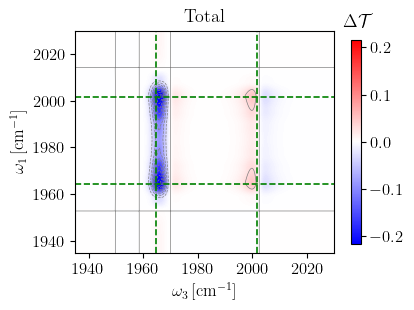

In [30]:
# --- Use real data limits ---
v = np.nanmax(np.abs(Z2plot)/5)
norm_real = Normalize(vmin=-v, vmax=v)

extent = [freq_t[0]*10 + 1983.5, freq_t[-1]*10 + 1983.5,
          freq_tau1[0]*10 + 1983.5, freq_tau1[-1]*10 + 1983.5]

center = 1983
delta = 18.5
positions = [center - delta, center + delta]

with mpl.rc_context({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'axes.labelsize': 12,
    'font.size': 12,
    'axes.titlesize': 13,
}):

    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    fig.set_layout_engine(None)

    im = ax.imshow(
        Z2plot.T/4,
        extent=extent,
        aspect='auto',
        cmap='bwr',
        origin='lower',
        norm=norm_real
    )

    ax.contour(
        Z2plot.T/5,
        levels=10,
        colors='gray',
        linewidths=0.5,
        extent=extent
    )

       # --- Add dashed green guide lines ---
    for pos in positions:
        ax.axvline(pos, color='green', linestyle='--', linewidth=1.2)
        ax.axhline(pos, color='green', linestyle='--', linewidth=1.2)

    ax.set_title(r"Total", pad=6)
    ax.set_xlabel(r"$\omega_3\, [\mathrm{cm}^{-1}]$")
    ax.set_ylabel(r"$\omega_1\, [\mathrm{cm}^{-1}]$")
    ax.set_xlim(1935, 2030)
    ax.set_ylim(1935, 2030)



    cbar = fig.colorbar(im, ax=ax, shrink=0.92)
    cbar.ax.set_title(r"$\Delta\mathcal{T}$", pad=8)

    fig.subplots_adjust(left=0.14, right=0.95, bottom=0.14, top=0.88)

    plt.show()
    fig.savefig("totalanh.pdf", format="pdf", bbox_inches="tight")